# **Estudio de Predictores de Diabetes en la Población Estadounidense 2022**

**Descripción:**  
En este análisis exploratorio (EDA) utilizamos el dataset `heart_2022_no_nans.csv` para identificar y caracterizar los principales factores asociados a la aparición de diabetes en adultos de Estados Unidos durante 2022. El objetivo es comprender la distribución de las variables clave, detectar correlaciones relevantes y sentar las bases para un posible modelo predictivo.

**Objetivos:**  
1. Describir la distribución de variables demográficas y de salud relacionadas con la diabetes (BMI, actividad física, tabaquismo, etc.).  
2. Identificar correlaciones y patrones entre predictores potenciales y la presencia de diabetes.  
3. Detectar valores atípicos y evaluar la calidad de los datos.  
4. Proponer próximos pasos para un modelo predictivo.

**Fuente de datos:**  
- link: https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease?select=2022
- Archivo: `heart_2022_no_nans.csv` (246 022 registros, 40 variables, sin valores nulos).   


---



## **Información general de los Datos**

El dataset contiene 40 variables que se clasifican en dos grandes grupos:

### Variables numéricas (6)
- `PhysicalHealthDays`: Número de días en el último mes con mala salud física.  
- `MentalHealthDays`: Número de días en el último mes con mala salud mental.  
- `SleepHours`: Horas promedio de sueño por noche.  
- `HeightInMeters`: Altura en metros.  
- `WeightInKilograms`: Peso en kilogramos.  
- `BMI`: Índice de Masa Corporal.

### Variables categóricas (34)
- `State`: Estado de residencia en EE. UU.  
- `Sex`: Sexo del encuestado.  
- `GeneralHealth`: Autopercepción del estado de salud general.  
- `LastCheckupTime`: Tiempo desde la última revisión médica.  
- `PhysicalActivities`: Realiza actividad física regularmente (Sí/No).  
- `RemovedTeeth`: Número de dientes extraídos.  
- `HadHeartAttack`, `HadAngina`, `HadStroke`, `HadAsthma`, `HadSkinCancer`, `HadCOPD`, `HadDepressiveDisorder`, `HadKidneyDisease`, `HadArthritis`, `HadDiabetes`: Antecedentes de condiciones de salud (Sí/No).  
- `DeafOrHardOfHearing`, `BlindOrVisionDifficulty`: Discapacidades sensoriales (auditiva y visual).  
- `DifficultyConcentrating`, `DifficultyWalking`, `DifficultyDressingBathing`, `DifficultyErrands`: Dificultades funcionales en tareas diarias (Sí/No).  
- `SmokerStatus`: Estado de fumador (Nunca, Ex-fumador, Fumador).  
- `ECigaretteUsage`: Uso de cigarrillos electrónicos (Sí/No).  
- `ChestScan`: Realización de escáner de tórax (Sí/No).  
- `RaceEthnicityCategory`: Categoría de raza o etnia.  
- `AgeCategory`: Categoría de edad.  
- `AlcoholDrinkers`: Consumo de alcohol en el último mes (Sí/No).  
- `HIVTesting`: Prueba de VIH alguna vez (Sí/No).  
- `FluVaxLast12`: Vacunación contra la gripe en los últimos 12 meses (Sí/No).  
- `PneumoVaxEver`: Vacunación antineumocócica alguna vez (Sí/No).  
- `TetanusLast10Tdap`: Vacunación de tétanos (Tdap) en los últimos 10 años (Sí/No).  
- `HighRiskLastYear`: Exposición a entornos de alto riesgo COVID-19 en el último año (Sí/No).  
- `CovidPos`: Resultado positivo de COVID-19 en el último año (Sí/No).

---

## **Análisis Exploratorio de los Datos**

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [10]:
#Dataset
df_original= pd.read_csv('heart_2022_no_nans.csv')
df= df_original.copy()

In [11]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [14]:
df.columns = ['estado' , 'sexo' , 'salud_general' , 'dias_salud_fisica' , 'dias_salud_mental' , 'ultimo_chequeo' , 'actividades_fisicas' , 'horas_sueño' , 'dientes_removidos' , 'ataque_cardiaco' , 'angina' , 'ACV' , 'asma' , 'cancer_piel' , 'EPOC' , 'trastorno_depre' , 'enfermedad_riñon' , 'artritis' , 'diabetes' , 'sordo_semisordo' , 'ciego_semiciego' , 'dif_concentracion' , 'dif_caminar' , 'dif_vestirduchar' , 'dif_encargo' ,'estado_fumador' , 'uso_cigarroelect' , 'escaner_torax' , 'categoria_etnica' , 'categoria_edad' , 'altura_metros' , 'peso_kilos' , 'bmi' , 'bebedor_alcohol' , 'prueba_VIH' , 'gripa_vac' , 'pneumo' , 'tetanos' , 'alto_riesgo_ap' , 'covid']
df.columns

Index(['estado', 'sexo', 'salud_general', 'dias_salud_fisica',
       'dias_salud_mental', 'ultimo_chequeo', 'actividades_fisicas',
       'horas_sueño', 'dientes_removidos', 'ataque_cardiaco', 'angina', 'ACV',
       'asma', 'cancer_piel', 'EPOC', 'trastorno_depre', 'enfermedad_riñon',
       'artritis', 'diabetes', 'sordo_semisordo', 'ciego_semiciego',
       'dif_concentracion', 'dif_caminar', 'dif_vestirduchar', 'dif_encargo',
       'estado_fumador', 'uso_cigarroelect', 'escaner_torax',
       'categoria_etnica', 'categoria_edad', 'altura_metros', 'peso_kilos',
       'bmi', 'bebedor_alcohol', 'prueba_VIH', 'gripa_vac', 'pneumo',
       'tetanos', 'alto_riesgo_ap', 'covid'],
      dtype='object')

Se han reemplazado los nombres de las columnas por su traduccion al español.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   estado               246022 non-null  object 
 1   sexo                 246022 non-null  object 
 2   salud_general        246022 non-null  object 
 3   dias_salud_fisica    246022 non-null  float64
 4   dias_salud_mental    246022 non-null  float64
 5   ultimo_chequeo       246022 non-null  object 
 6   actividades_fisicas  246022 non-null  object 
 7   horas_sueño          246022 non-null  float64
 8   dientes_removidos    246022 non-null  object 
 9   ataque_cardiaco      246022 non-null  object 
 10  angina               246022 non-null  object 
 11  ACV                  246022 non-null  object 
 12  asma                 246022 non-null  object 
 13  cancer_piel          246022 non-null  object 
 14  EPOC                 246022 non-null  object 
 15  trastorno_depre  

In [16]:
#Descripción estadística
df.describe()

,dias_salud_fisica,dias_salud_mental,horas_sueño,altura_metros,peso_kilos,bmi
count,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000
mean,4.119026,4.167140,7.021331,1.705150,83.615179,28.668136
std,8.405844,8.102687,1.440681,0.106654,21.323156,6.513973
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.270000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.460000
75%,3.000000,4.000000,8.000000,1.780000,95.250000,31.890000
max,30.000000,30.000000,24.000000,2.410000,292.570000,97.650000


Este resumen estadístico incluye medidas clave para seis variables cuantitativas del conjunto de datos, el cual contiene **246,022 registros**:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  Representan la cantidad de días en el último mes que la persona reportó mala salud física o mental, respectivamente.  
  - Promedio de aproximadamente **4 días**, pero con una **mediana de 0**, lo que indica que más del 50% de los encuestados no reportó problemas de salud en ese periodo.  
  - Valor máximo de **30 días**, indicando presencia de personas con malestar continuo durante todo el mes.

- **`horas_sueño`**  
  Número de horas de sueño que reporta la persona por noche.  
  - Promedio de **7 horas**, considerado dentro del rango saludable.  
  - Rango desde **1 hasta 24 horas**, lo que sugiere posibles valores atípicos o errores de reporte.

- **`altura_metros` y `peso_kilos`**  
  Medidas antropométricas del individuo.  
  - Altura media: **1.70 metros**  
  - Peso medio: **83.6 kg**  
  - Se observan valores extremos: altura máxima de **2.41 m** y peso máximo de **292.57 kg**, lo que podría requerir revisión o limpieza.

- **`bmi` (índice de masa corporal)**  
  Calculado con base en el peso y la altura.  
  - Promedio de **28.7**, clasificado como **sobrepeso** según la OMS.  
  - Rango de **12.0 a 97.65**, que incluye tanto casos de bajo peso como de obesidad extrema, posibles outliers o errores.

In [17]:
#Valores duplicados
print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())


Número de filas duplicadas:
9


In [18]:
df[df.duplicated()]

,estado,sexo,salud_general,dias_salud_fisica,dias_salud_mental,ultimo_chequeo,actividades_fisicas,horas_sueño,dientes_removidos,ataque_cardiaco,...,altura_metros,peso_kilos,bmi,bebedor_alcohol,prueba_VIH,gripa_vac,pneumo,tetanos,alto_riesgo_ap,covid
5702,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.70,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
87555,Maryland,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.65,45.36,16.64,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
88402,Maryland,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.75,65.77,21.41,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
137645,New Jersey,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.63,80.74,30.55,Yes,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
174923,Rhode Island,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,...,1.57,68.04,27.44,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
184137,South Dakota,Female,Fair,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.75,90.72,29.53,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
208013,Vermont,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.65,79.38,29.12,Yes,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
216362,Washington,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.80,77.11,23.71,Yes,Yes,Yes,No,"Yes, received Tdap",No,No
225974,Washington,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.93,104.33,28.00,Yes,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [19]:
df= df.drop_duplicates() #limpiamos los duplicados

In [20]:
# Comprobamos limpieza
df.duplicated().sum()

np.int64(0)

## **Análisis de variable numéricas**

In [22]:
num_cols = df.select_dtypes(include="number").columns
df.select_dtypes(include="number").columns

Index(['dias_salud_fisica', 'dias_salud_mental', 'horas_sueño',
       'altura_metros', 'peso_kilos', 'bmi'],
      dtype='object')

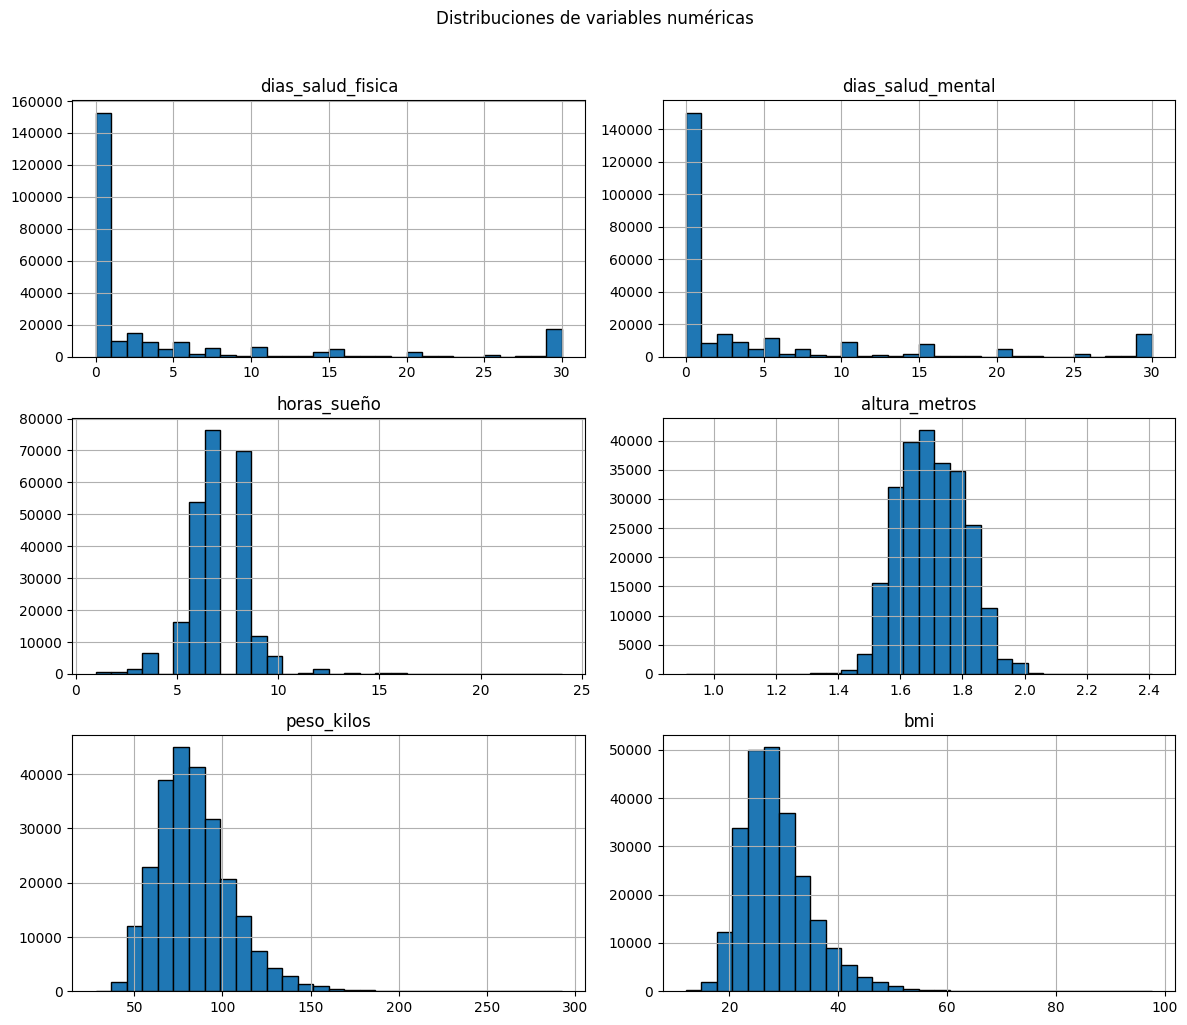

In [23]:
# Histograma para distribución de variables numéricas
df[num_cols].hist(bins=30, figsize=(12, 10), edgecolor='black')
plt.suptitle("Distribuciones de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

 Se presentan las distribuciones de seis variables numéricas clave del conjunto de datos, que permiten observar la forma de los datos y la presencia de posibles valores atípicos:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  Ambas variables muestran una distribución fuertemente **asimétrica a la derecha (sesgada positiva)**, con un alto número de personas que reportan **0 días de mala salud** en el último mes. También se observa un pequeño pico en el valor **30**, lo que podría representar personas con malestar persistente o respuestas extremas.

- **`horas_sueño`**  
  La distribución tiene una forma **aproximadamente normal**, centrada entre **6 y 8 horas** por noche. Existen pocos casos extremos con menos de 4 o más de 12 horas, lo cual podría indicar hábitos poco comunes o errores.

- **`altura_metros`**  
  Presenta una **distribución simétrica y normal**, centrada alrededor de **1.7 metros**, lo esperado en una población general.

- **`peso_kilos`**  
  Exhibe una distribución **asimétrica a la derecha**, indicando que la mayoría de las personas pesan entre **60 y 100 kg**, pero existen casos con pesos significativamente mayores, que podrían ser atípicos.

- **`bmi` (índice de masa corporal)**  
  También muestra una **asimetría a la derecha**, con una concentración de individuos en rangos de sobrepeso (**25-30**) y obesidad (**>30**). Hay valores superiores a **60**, que podrían ser casos extremos o errores de digitación.


## **Análisis de Outliers**

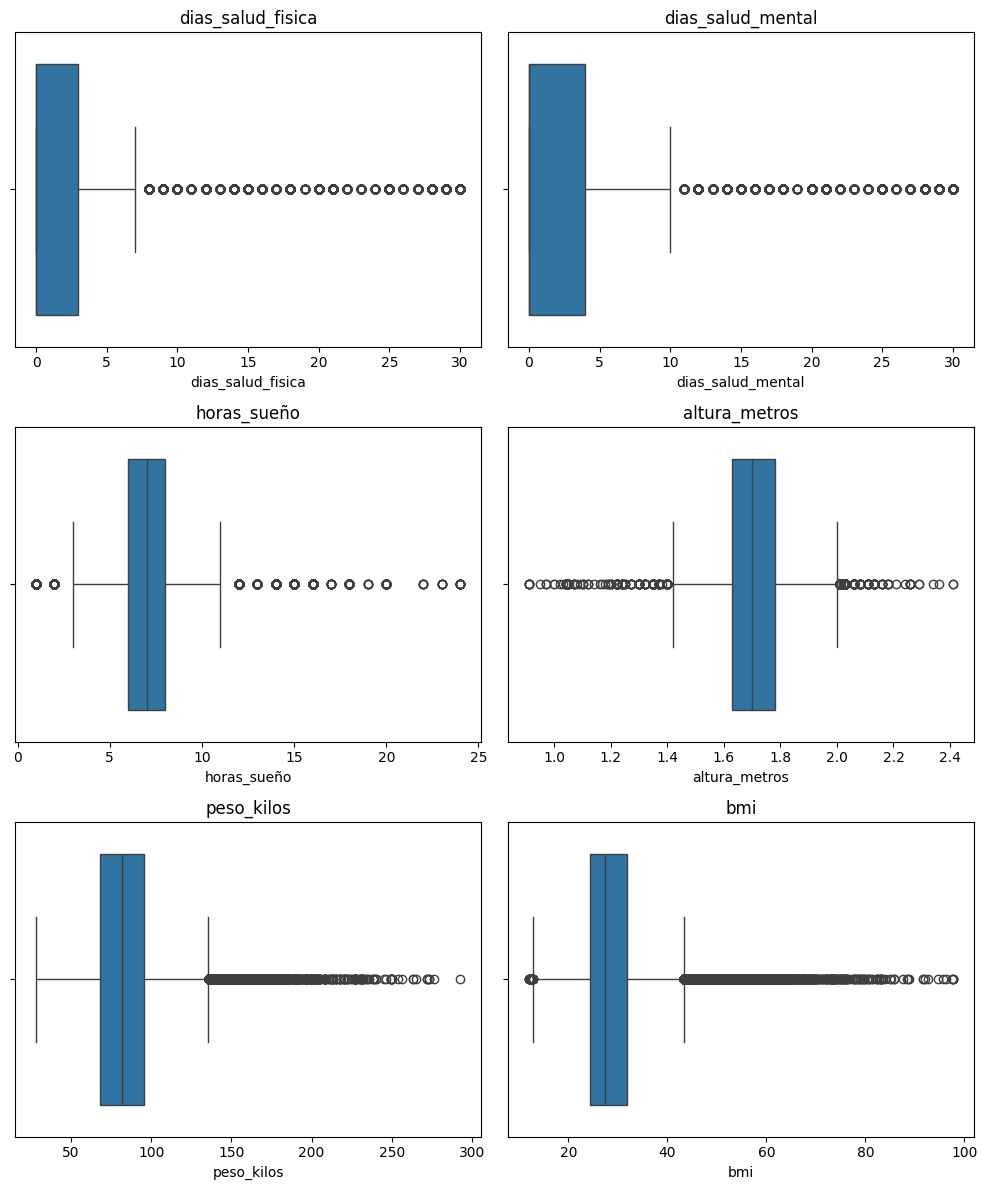

In [25]:
plots_per_row = 2
n = len(num_cols)
rows = math.ceil(n/plots_per_row)
fig, axes = plt.subplots(rows, plots_per_row, figsize=(5*plots_per_row,4*rows))
for i, col in enumerate(num_cols):
  ax = axes.flatten()[i]
  sns.boxplot(x=df[col], ax=ax).set_title(col)
for ax in axes.flatten()[n:]: fig.delaxes(ax)
plt.tight_layout()

Los diagramas de caja permiten visualizar la dispersión de los datos y la presencia de **valores atípicos** (outliers) en cada variable. A continuación, se describe lo observado en cada caso:

- **`dias_salud_fisica` y `dias_salud_mental`**  
  - La mayoría de los valores están concentrados entre 0 y 5 días.
  - Existen numerosos **valores atípicos hacia la derecha**, especialmente en **30 días**, lo que puede representar respuestas extremas (posiblemente personas con malestar todo el mes).

- **`horas_sueño`**  
  - La mediana se encuentra cerca de las 7 horas.
  - Hay outliers tanto en valores bajos (< 4 h) como altos (> 12 h), lo cual podría reflejar hábitos extremos o errores en la respuesta.

- **`altura_metros`**  
  - Tiene una distribución más simétrica.
  - Se identifican valores atípicos por debajo de 1.3 m y por encima de 2.1 m, lo cual puede ser real o deberse a errores de captura.

- **`peso_kilos`**  
  - Se identifican muchos **outliers por exceso**, especialmente en pesos mayores a 150 kg.
  - Aunque hay una tendencia normal, la dispersión sugiere una posible revisión o tratamiento de valores extremos.

- **`bmi` (índice de masa corporal)**  
  - Muestra una concentración de datos en rangos de sobrepeso y obesidad.
  - Presenta numerosos valores atípicos hacia la derecha, superando incluso los **60 puntos de IMC**, lo cual podría representar condiciones médicas graves o errores de digitación.


## **Análisis de Variables Categoricas Relevantes**

In [26]:
# 4. Análisis de variables categóricas
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['estado', 'sexo', 'salud_general', 'ultimo_chequeo',
       'actividades_fisicas', 'dientes_removidos', 'ataque_cardiaco', 'angina',
       'ACV', 'asma', 'cancer_piel', 'EPOC', 'trastorno_depre',
       'enfermedad_riñon', 'artritis', 'diabetes', 'sordo_semisordo',
       'ciego_semiciego', 'dif_concentracion', 'dif_caminar',
       'dif_vestirduchar', 'dif_encargo', 'estado_fumador', 'uso_cigarroelect',
       'escaner_torax', 'categoria_etnica', 'categoria_edad',
       'bebedor_alcohol', 'prueba_VIH', 'gripa_vac', 'pneumo', 'tetanos',
       'alto_riesgo_ap', 'covid'],
      dtype='object')

In [27]:
for col in cat_cols:
    print(f"\n Columna: {col}")
    print(df[col].value_counts(dropna=False))


 Columna: estado
estado
Washington              14998
Maryland                 9163
Minnesota                9161
Ohio                     8995
New York                 8923
Texas                    7408
Florida                  7315
Kansas                   6145
Wisconsin                6126
Maine                    6013
Iowa                     5672
Hawaii                   5596
Virginia                 5565
Indiana                  5502
South Carolina           5471
Massachusetts            5465
Arizona                  5461
Utah                     5373
Michigan                 5370
Colorado                 5159
Nebraska                 5107
California               5096
Connecticut              5053
Georgia                  4978
Vermont                  4844
South Dakota             4404
Montana                  4264
Missouri                 4195
New Jersey               3966
New Hampshire            3756
Puerto Rico              3589
Idaho                    3468
Alaska         

In [28]:
# Reemplazar las clases por 'No'
df["diabetes"] = df["diabetes"].replace({
    "Yes, but only during pregnancy (female)": "No",
    "No, pre-diabetes or borderline diabetes": "No"
})
df['diabetes'].value_counts()

diabetes
No     212202
Yes     33811
Name: count, dtype: int64

In [29]:
df['sexo'].value_counts(normalize=True)

sexo
Female    0.519509
Male      0.480491
Name: proportion, dtype: float64

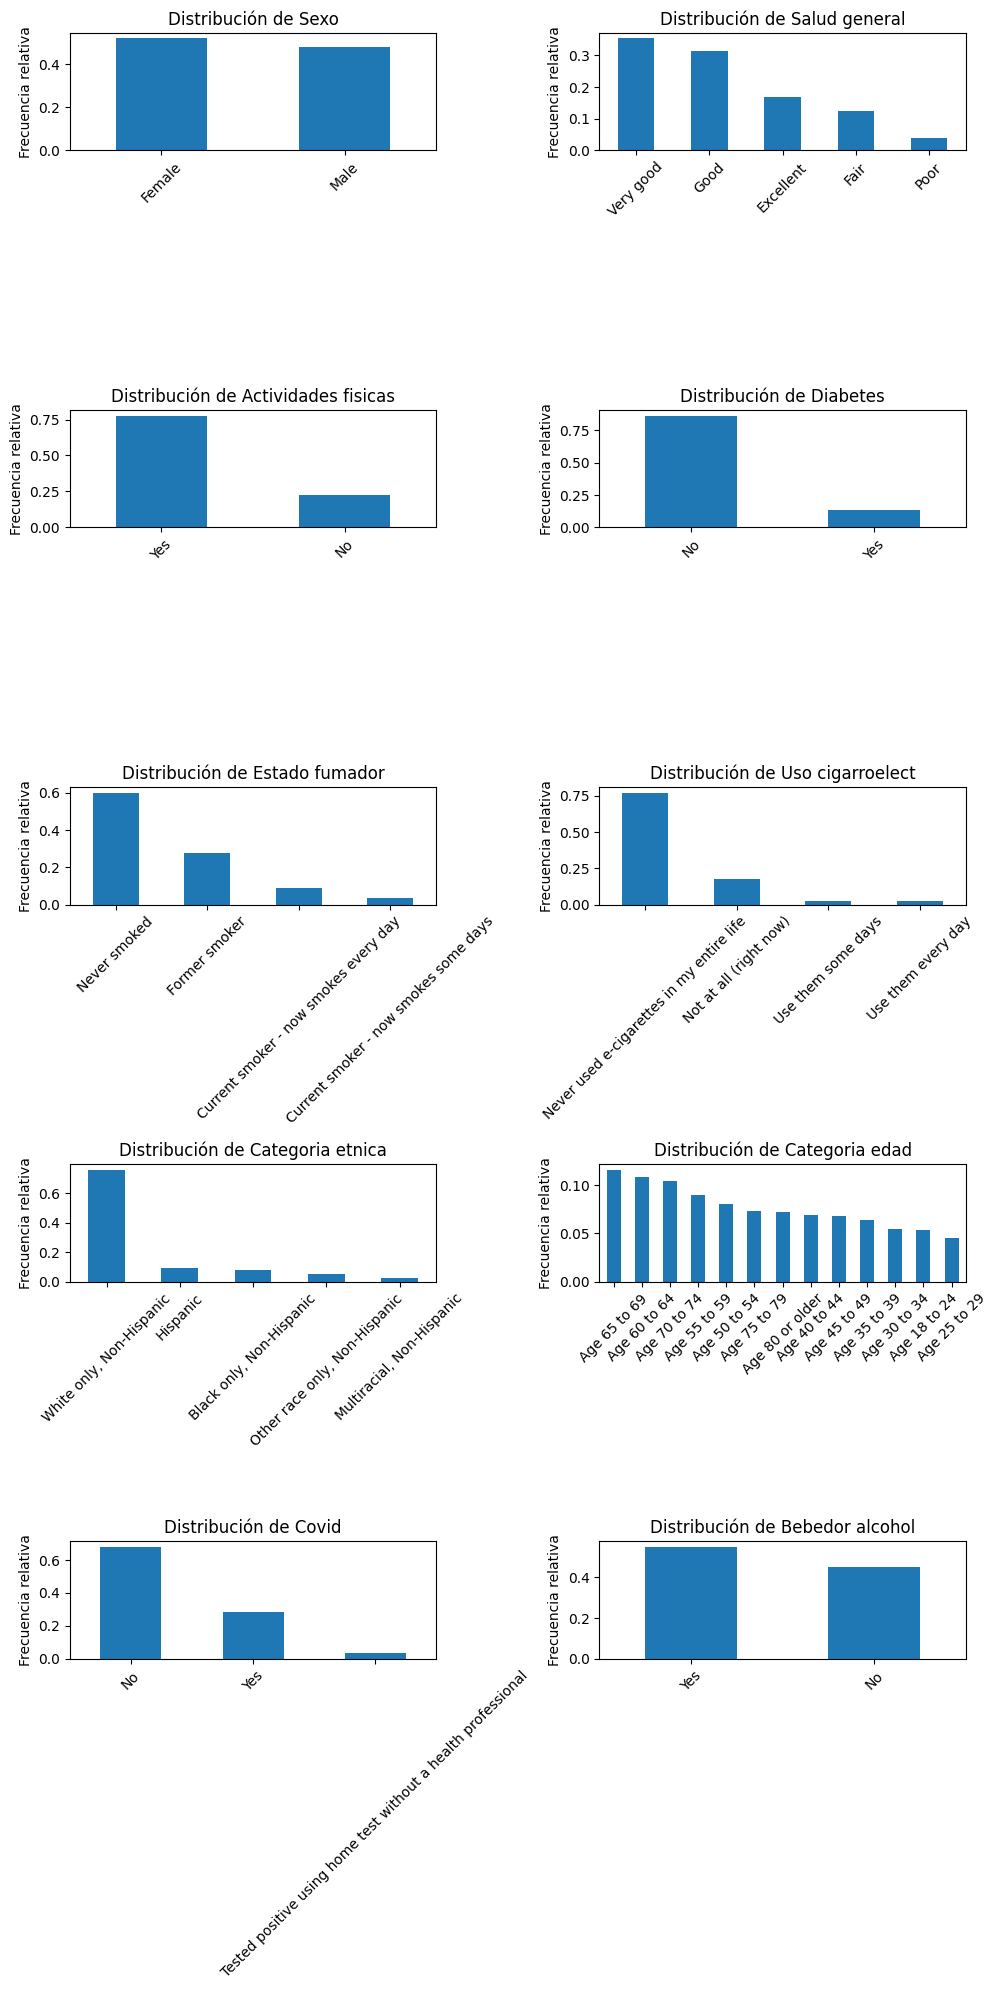

In [30]:
# Lista de variables a graficar
vars = [
    'sexo', 'salud_general', 'actividades_fisicas', 'diabetes',
    'estado_fumador', 'uso_cigarroelect', 'categoria_etnica',
    'categoria_edad', 'covid', 'bebedor_alcohol'
]

# Parámetros de la cuadrícula
per_row = 2
n = len(vars)
rows = math.ceil(n / per_row)

# Crear figura y ejes
fig, axes = plt.subplots(rows, per_row, figsize=(5*per_row, 4*rows), squeeze=False)

# Loop para generar cada gráfico
for ax, var in zip(axes.flat, vars):
    df[var].value_counts(normalize=True) \
           .plot(kind='bar', ax=ax)
    ax.set_title(f"Distribución de {var.replace('_', ' ').capitalize()}")
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia relativa')
    ax.tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si los hay
for ax in axes.flat[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

Los gráficos muestran la distribución relativa de distintas variables categóricas relevantes para el análisis de salud. A continuación, se resume lo observado:

- **Sexo**  
  - Distribución equilibrada entre hombres y mujeres.

- **Salud general**  
  - La mayoría de los participantes se consideran con salud **“Muy buena” o “Buena”**.
  - Pocas personas se califican con salud **“Pobre”**.

- **Actividades físicas**  
  - Alrededor del **65%** de los encuestados reportan realizar actividad física.

- **Diabetes**  
  - Más de la mitad no presenta diabetes.
  - Una pequeña proporción reporta haber tenido diabetes durante el embarazo o prediabetes.

- **Estado fumador**  
  - Predominan quienes **nunca han fumado**, seguidos por **exfumadores**.
  - Los fumadores actuales son minoría.

- **Uso de cigarrillos electrónicos**  
  - Mayoría nunca ha usado cigarrillos electrónicos.
  - Bajo uso diario o frecuente.

- **Categoría étnica**  
  - Predominio de personas **blancas no hispanas**.
  - Minorías étnicas representan porcentajes mucho menores.

- **Categoría de edad**  
  - La muestra está bien distribuida, aunque destaca el grupo de edad **65–69 años** como el más representado.
  - Se observa una disminución progresiva hacia los grupos de menor edad.

- **Covid**  
  - Mayoría no ha reportado infección por COVID-19.
  - Una fracción pequeña reportó test positivo.

- **Bebedor de alcohol**  
  - Ligera mayoría indicó consumir alcohol.

## **Correlación entre variables numéricas**

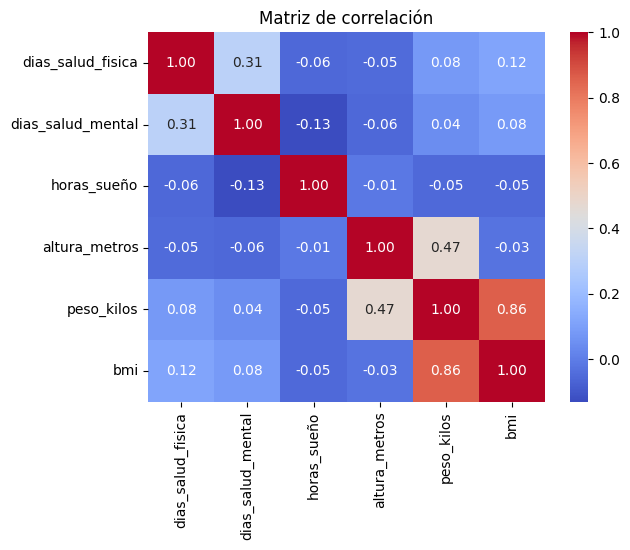

In [31]:
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación muestra la relación lineal entre variables numéricas del conjunto de datos. Los valores van de **-1 a 1**, donde:

- **1** indica una correlación positiva perfecta.
- **0** indica ausencia de correlación lineal.
- **-1** indica una correlación negativa perfecta.

### **Principales observaciones**:

- **`peso_kilos` y `bmi`**:  
  - Fuerte correlación positiva (**0.86**), lo esperado ya que el índice de masa corporal (IMC) depende directamente del peso.

- **`altura_metros` y `peso_kilos`**:  
  - Correlación moderada (**0.47**), lo cual indica que las personas más altas tienden a pesar más, aunque no linealmente.

- **`dias_salud_fisica` y `dias_salud_mental`**:  
  - Correlación positiva moderada (**0.31**), lo cual sugiere que quienes reportan mala salud física también tienden a reportar malestar mental.

- **`horas_sueño`**:  
  - Muestra **baja o nula correlación** con las demás variables, indicando que el número de horas dormidas no está linealmente relacionado con salud física, mental o medidas corporales.

- **`bmi` y `dias_salud_fisica`**:  
  - Correlación baja pero positiva (**0.12**), lo que podría sugerir que valores más altos de IMC están ligeramente asociados a más días de mala salud física.

## **Analisis bivariado**

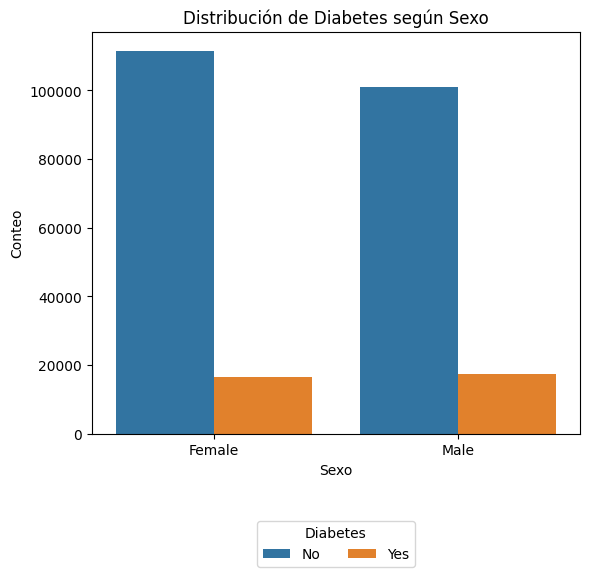

In [32]:
plt.figure(figsize=(6, 6))
sns.countplot(x='sexo', hue='diabetes', data=df)
plt.title('Distribución de Diabetes según Sexo')
plt.xlabel('Sexo')
plt.ylabel('Conteo')
# Colocar la leyenda debajo del gráfico
plt.legend(title='Diabetes',
           loc='upper center',
           bbox_to_anchor=(0.5, -0.20),
           ncol=2)
plt.tight_layout()
plt.show()

El gráfico muestra que la mayoría de los encuestados, tanto hombres como mujeres, **no presentan diabetes**. Sin embargo, se observa una **proporción ligeramente mayor de hombres con diagnóstico de diabetes** en comparación con las mujeres. Además, solo las mujeres reportan casos de diabetes **durante el embarazo**, como era de esperarse. También se identifican casos de **prediabetes o diabetes limítrofe** en ambos sexos, aunque en menor proporción.


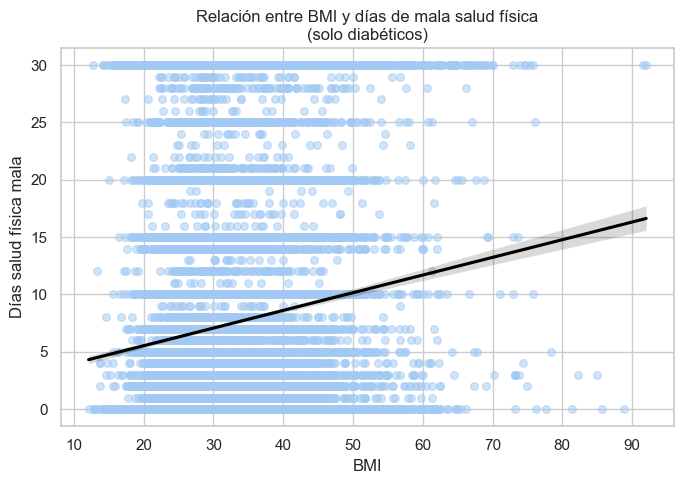

In [33]:
df_diab = df[df['diabetes']=='Yes'].copy()
sns.set(style='whitegrid', palette='pastel')
plt.figure(figsize=(7,5))
sns.regplot(
    x='bmi',
    y='dias_salud_fisica',
    data=df_diab,
    scatter_kws={'alpha':0.5, 's':30},
    line_kws={'color':'black'}
)
plt.title('Relación entre BMI y días de mala salud física\n(solo diabéticos)')
plt.xlabel('BMI')
plt.ylabel('Días salud física mala')
plt.tight_layout()
plt.show()

El gráfico muestra una **relación positiva** entre el índice de masa corporal (BMI) y los **días de mala salud física** en personas con diabetes. A medida que el BMI aumenta, también tiende a aumentar el número de días reportados con malestar físico. Aunque la dispersión es alta, la **tendencia general** sugiere que un mayor BMI podría estar asociado con una peor condición física en personas diabéticas.


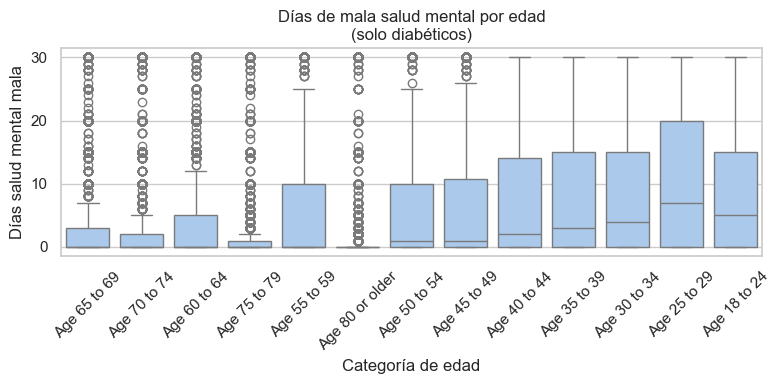

In [34]:
plt.figure(figsize=(8,4))
order_edad = df_diab['categoria_edad'].value_counts().index
sns.boxplot(
    x='categoria_edad',
    y='dias_salud_mental',
    data=df_diab,
    order=order_edad
)
plt.title('Días de mala salud mental por edad\n(solo diabéticos)')
plt.xlabel('Categoría de edad')
plt.ylabel('Días salud mental mala')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El gráfico muestra la distribución de **días de mala salud mental** entre personas con diabetes, segmentadas por categoría de edad. Se observa una **tendencia clara**: los grupos de edad más jóvenes (especialmente entre **18 y 34 años**) reportan **más días de malestar mental** en promedio, mientras que los adultos mayores tienden a reportar **menos días de afectación**. Esta diferencia sugiere una posible **vulnerabilidad emocional o psicológica mayor en personas jóvenes con diabetes**, en comparación con los grupos mayores.


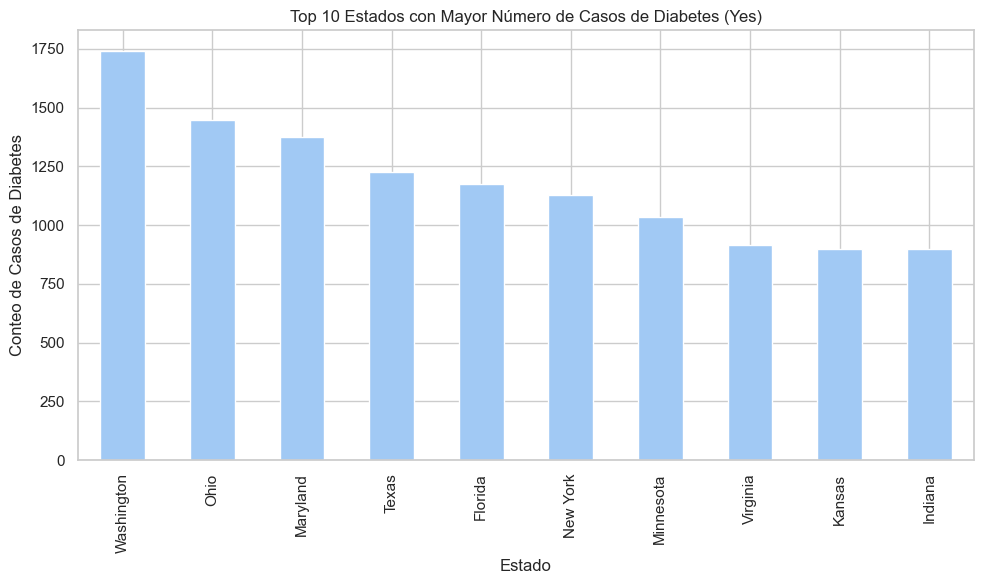

In [35]:
top10_estados = df[df['diabetes'] == 'Yes']['estado'].value_counts().head(10)

# 3. Graficar
plt.figure(figsize=(10, 6))
top10_estados.plot(kind='bar')
plt.title('Top 10 Estados con Mayor Número de Casos de Diabetes (Yes)')
plt.xlabel('Estado')
plt.ylabel('Conteo de Casos de Diabetes')
plt.tight_layout()
plt.show()

El gráfico presenta los **10 estados con mayor número de casos de diabetes diagnosticada** (respuesta "Yes"). **Washington** encabeza la lista con la mayor cantidad de personas con diabetes, seguido por **Ohio** y **Maryland**. Estos resultados permiten identificar regiones con una mayor carga de esta enfermedad, lo cual podría estar relacionado con factores sociodemográficos, acceso a servicios de salud o estilos de vida particulares de cada estado.


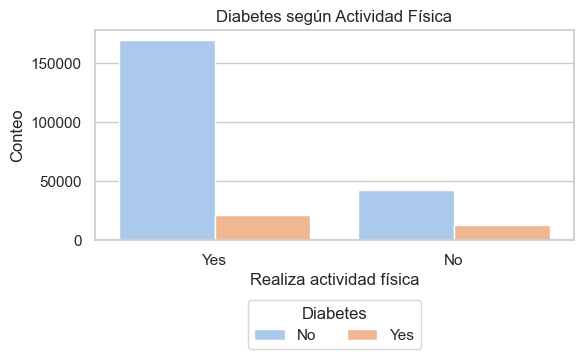

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(x='actividades_fisicas', hue='diabetes', data=df)
plt.title('Diabetes según Actividad Física')
plt.xlabel('Realiza actividad física')
plt.ylabel('Conteo')
plt.legend(
    title='Diabetes',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2
)
plt.tight_layout()
plt.show()

El gráfico muestra la relación entre la actividad física y la presencia de diabetes. Se observa que la **mayoría de las personas que realizan actividad física no tienen diabetes**. Sin embargo, también hay casos de diabetes entre quienes sí realizan ejercicio, aunque en menor proporción que entre quienes no lo hacen. En el grupo que **no realiza actividad física**, la proporción de personas con diabetes es **visiblemente mayor**, lo que sugiere una posible **asociación negativa entre la inactividad física y el diagnóstico de diabetes**.
